<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><ul class="toc-item"><li><span><a href="#Packages" data-toc-modified-id="Packages-0.1"><span class="toc-item-num">0.1&nbsp;&nbsp;</span>Packages</a></span></li><li><span><a href="#Barplot-config" data-toc-modified-id="Barplot-config-0.2"><span class="toc-item-num">0.2&nbsp;&nbsp;</span>Barplot config</a></span></li><li><span><a href="#Load-dump" data-toc-modified-id="Load-dump-0.3"><span class="toc-item-num">0.3&nbsp;&nbsp;</span>Load dump</a></span></li></ul></li><li><span><a href="#Extract-Words" data-toc-modified-id="Extract-Words-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Extract Words</a></span></li><li><span><a href="#Spelling" data-toc-modified-id="Spelling-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Spelling</a></span><ul class="toc-item"><li><span><a href="#Words-with-[p]-,-[m]-,-[lh]-and-[nh]" data-toc-modified-id="Words-with-[p]-,-[m]-,-[lh]-and-[nh]-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>Words with [p] , [m] , [lh] and [nh]</a></span><ul class="toc-item"><li><span><a href="#[p]" data-toc-modified-id="[p]-2.1.1"><span class="toc-item-num">2.1.1&nbsp;&nbsp;</span>[p]</a></span></li><li><span><a href="#[m]" data-toc-modified-id="[m]-2.1.2"><span class="toc-item-num">2.1.2&nbsp;&nbsp;</span>[m]</a></span></li><li><span><a href="#[lh]" data-toc-modified-id="[lh]-2.1.3"><span class="toc-item-num">2.1.3&nbsp;&nbsp;</span>[lh]</a></span></li><li><span><a href="#[nh]" data-toc-modified-id="[nh]-2.1.4"><span class="toc-item-num">2.1.4&nbsp;&nbsp;</span>[nh]</a></span></li></ul></li><li><span><a href="#Results" data-toc-modified-id="Results-2.2"><span class="toc-item-num">2.2&nbsp;&nbsp;</span>Results</a></span></li></ul></li></ul></div>

## Packages

In [1]:
import os
import re

import codecs
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches

## Barplot config

In [2]:
sns.set(color_codes=True)

def show_values_on_bars_v(axs):
    x1,x2,y1,y2 = plt.axis()
    plt.axis((x1,x2,y1 ,y2))
    def _show_on_single_plot(ax):        
        for p in ax.patches:
            _x = p.get_x() - 0.01 + p.get_width() / 2.
            _y = p.get_y() + p.get_height() * 1.02
            value = '{:.3f}%'.format(p.get_height()*100)
            ax.text(_x, _y+0.3, value, ha="center") 

    if isinstance(axs, np.ndarray):
        for idx, ax in np.ndenumerate(axs):
            _show_on_single_plot(ax)
    else:
        _show_on_single_plot(axs)
        
def show_values_on_bars_h(axs):
    x1,x2,y1,y2 = plt.axis()
    plt.axis((x1,x2,y1 ,y2))
    def _show_on_single_plot(ax):        
        for p in ax.patches:
            _x = p.get_x() + p.get_width() #+ 0.4
            _y = p.get_y() + p.get_height()
            value = '{:.3f}%'.format(p.get_width()*100)
            ax.text(_x, _y, value, ha="left")

    if isinstance(axs, np.ndarray):
        for idx, ax in np.ndenumerate(axs):
            _show_on_single_plot(ax)
    else:
        _show_on_single_plot(axs)
        

def show_values_on_bars_reg_v(axs):
    x1,x2,y1,y2 = plt.axis()
    plt.axis((x1,x2,y1 ,y2 + 8))
    def _show_on_single_plot(ax):        
        for p in ax.patches:
            _x = p.get_x() - 0.01 + p.get_width() / 2.
            _y = p.get_y() + p.get_height() * 1.02
            value = '{:.0f}'.format(p.get_height())
            ax.text(_x, _y+0.3, value, ha="center") 

    if isinstance(axs, np.ndarray):
        for idx, ax in np.ndenumerate(axs):
            _show_on_single_plot(ax)
    else:
        _show_on_single_plot(axs)
        
def show_values_on_bars_reg_h(axs):
    x1,x2,y1,y2 = plt.axis()
    plt.axis((x1,x2+8,y1 ,y2))
    def _show_on_single_plot(ax):        
        for p in ax.patches:
            _x = p.get_x() + p.get_width() + 0.4
            _y = p.get_y() + p.get_height()
            value = '{:.0f}'.format(p.get_width())
            ax.text(_x, _y, value, ha="left")

    if isinstance(axs, np.ndarray):
        for idx, ax in np.ndenumerate(axs):
            _show_on_single_plot(ax)
    else:
        _show_on_single_plot(axs)

## Load dump
Galician wiktionary from https://dumps.wikimedia.org/glwiktionary/latest/

7-10-2023

In [3]:
gl_dict = []

with open("glwiktionary-latest-pages-articles.xml", encoding="utf-8") as file:
    gl_dict = file.read()
print(len(gl_dict))

96257923


In [4]:
p_m_nh_lh_stats_list = []

# Extract Words

Words that have Portuguese and Spanish translation, as well as identified Latin etimology

In [5]:
#pt_dict = urllib.parse.unquote(pt_dict)
regex = r"(?<=\<page\>)(.*?)\s*(?=\<\/page\>)"
gl_entries= re.findall(regex, gl_dict, re.DOTALL)
len(gl_entries)

96395

In [6]:
word_search = "{{T|es}}"
gl_entries = [match for match in gl_entries if word_search in match]

word_search = "{{T|pt}}"
gl_entries = [match for match in gl_entries if word_search in match]

word_search = "{{orixe|la|gl}}"
gl_entries = [match for match in gl_entries if word_search in match]

In [7]:
len(gl_entries)
p_m_nh_lh_stats_list.append(["word_all",len(gl_entries)])

In [8]:
regex = r"(?<=\<title\>)(.*)(?=\<\/title\>)"
gl_entries_ort = [re.findall(regex, i)[0] for i in gl_entries]
gl_entries_ort[0:10] 

['dicionario',
 'e',
 'xaneiro',
 'febreiro',
 'marzo',
 'abril',
 'xuño',
 'xullo',
 'novembro',
 'decembro']

In [9]:
regex = r"(?<=t\|pt\|)(\w*)(?=\}\})"
pt_entries_ort = [re.findall(regex, i, re.MULTILINE) for i in gl_entries]
pt_entries_ort = [[''] if s==[] else s for s in pt_entries_ort]
pt_entries_ort = [item[0] for item in pt_entries_ort]
pt_entries_ort[0:10] 

['dicionário',
 'é',
 'janeiro',
 'fevereiro',
 'março',
 'abril',
 'junho',
 'julho',
 'novembro',
 'dezembro']

In [10]:
regex = r"(?<=t\|es\|)(\w*)(?=\}\})"
es_entries_ort = [re.findall(regex, i, re.MULTILINE) for i in gl_entries]
es_entries_ort = [[''] if s==[] else s for s in es_entries_ort]
es_entries_ort = [item[0] for item in es_entries_ort]
es_entries_ort[0:10] 

['diccionario',
 'e',
 'enero',
 'febrero',
 'marzo',
 'abril',
 'junio',
 'julio',
 'noviembre',
 'diciembre']

In [11]:
regex = r"(?<=\{\{la\|)(\w*)(?=\W)"
la_entries_ort = [re.findall(regex, i, re.MULTILINE) for i in gl_entries]
la_entries_ort = [[''] if s==[] else s for s in la_entries_ort]
la_entries_ort = [item[0] for item in la_entries_ort]
la_entries_ort[0:10] 

['dictionarium',
 'et',
 'Ianuarius',
 '',
 'mensis',
 'Aprilis',
 'iunius',
 '',
 '',
 'december']

In [12]:
entries_df = pd.DataFrame()
entries_df["gl"] = gl_entries_ort
entries_df["pt"] = pt_entries_ort
entries_df["es"] = es_entries_ort
entries_df["la"] = la_entries_ort
entries_df[0:10]

,gl,pt,es,la
0,dicionario,dicionário,diccionario,dictionarium
1,e,é,e,et
2,xaneiro,janeiro,enero,Ianuarius
3,febreiro,fevereiro,febrero,
4,marzo,março,marzo,mensis
5,abril,abril,abril,Aprilis
6,xuño,junho,junio,iunius
7,xullo,julho,julio,
8,novembro,novembro,noviembre,
9,decembro,dezembro,diciembre,december


In [13]:
entries_df.to_csv("wikcionario_gl_pt_es_la.csv", index = False, header = True)

# Spelling

In [14]:
# in case the table is corrected
#entries_df = pd.read_csv('wikcionario_gl_pt_es_la.csv') 

## Words with [p] , [m] , [lh] and [nh]

### [p]

In [15]:
word_p_gl = entries_df[entries_df["gl"].str.contains("p")]
word_p_gl

,gl,pt,es,la
21,pelo,cabelo,pelo,pilus
22,pel,pele,piel,pellis
34,perna,perna,pierna,perna
45,pupila,menina,pupila,Pupilla
55,polgar,polegar,pulgar,
...,...,...,...,...
2571,propileo,propileu,propileo,propylaeum
2575,arcebispo,arcebispo,arzobispo,archiepiscŏpus
2577,depresión,depressão,depresión,depressio
2579,pretorio,pretório,pretorio,praetorium


In [16]:
count = word_p_gl.applymap(lambda x: x.count('p'))
p_m_nh_lh_stats_list.append(["p_gl",count.gl.sum()])
count.gl.sum()

545

In [17]:
word_p_pt = entries_df[entries_df["pt"].str.contains("p")]
word_p_pt

,gl,pt,es,la
22,pel,pele,piel,pellis
34,perna,perna,pierna,perna
55,polgar,polegar,pulgar,
63,pene,pênis,pene,penis
64,perfeba,pestana,pestaña,Palpetra
...,...,...,...,...
2571,propileo,propileu,propileo,propylaeum
2575,arcebispo,arcebispo,arzobispo,archiepiscŏpus
2577,depresión,depressão,depresión,depressio
2579,pretorio,pretório,pretorio,praetorium


In [18]:
count = word_p_pt.applymap(lambda x: x.count('p'))
p_m_nh_lh_stats_list.append(["p_pt",count.pt.sum()])
count.pt.sum()

550

In [19]:
word_p_es = entries_df[entries_df["es"].str.contains("p")]
word_p_es

,gl,pt,es,la
21,pelo,cabelo,pelo,pilus
22,pel,pele,piel,pellis
34,perna,perna,pierna,perna
45,pupila,menina,pupila,Pupilla
55,polgar,polegar,pulgar,
...,...,...,...,...
2571,propileo,propileu,propileo,propylaeum
2575,arcebispo,arcebispo,arzobispo,archiepiscŏpus
2577,depresión,depressão,depresión,depressio
2579,pretorio,pretório,pretorio,praetorium


In [20]:
count = word_p_es.applymap(lambda x: x.count('p'))
p_m_nh_lh_stats_list.append(["p_es",count.es.sum()])
count.es.sum()

549

In [21]:
word_p_la = entries_df[entries_df["la"].str.contains("p")]
word_p_la

,gl,pt,es,la
5,abril,abril,abril,Aprilis
20,cabeza,cabeça,cabeza,capitia
21,pelo,cabelo,pelo,pilus
22,pel,pele,piel,pellis
34,perna,perna,pierna,perna
...,...,...,...,...
2571,propileo,propileu,propileo,propylaeum
2575,arcebispo,arcebispo,arzobispo,archiepiscŏpus
2577,depresión,depressão,depresión,depressio
2579,pretorio,pretório,pretorio,praetorium


In [22]:
count = word_p_la.applymap(lambda x: x.count('p'))
count.la.sum()

648

### [m]

In [23]:
m_list = "m[aáàâãeéèêiíìoóòôõuúù]"
word_m_gl = entries_df[entries_df["gl"].str.contains(m_list)]
word_m_gl

,gl,pt,es,la
4,marzo,março,marzo,mensis
10,domingo,domingo,domingo,dominicus
12,martes,,martes,martis
13,mércores,,miércoles,dies
19,lágrima,lágrima,lágrima,lacrima
...,...,...,...,...
2573,crismón,,crismón,chrismon
2576,estramonio,,estramonio,stramonium
2580,pretorianismo,pretorianismo,pretorianismo,praetor
2581,meda,meda,hacina,meta


In [24]:
count = word_m_gl.applymap(lambda x: len(re.findall(m_list, x)))
p_m_nh_lh_stats_list.append(["m_gl",count.gl.sum()])
count.gl.sum()

487

In [25]:
word_m_pt = entries_df[entries_df["pt"].str.contains(m_list)]
word_m_pt

,gl,pt,es,la
4,marzo,março,marzo,mensis
10,domingo,domingo,domingo,dominicus
19,lágrima,lágrima,lágrima,lacrima
44,man,mão,mano,manum
45,pupila,menina,pupila,Pupilla
...,...,...,...,...
2564,hemorraxia,hemorragia,hemorragia,haemorragĭa
2570,eufemismo,eufemismo,eufemismo,euphemismus
2580,pretorianismo,pretorianismo,pretorianismo,praetor
2581,meda,meda,hacina,meta


In [26]:
count = word_m_pt.applymap(lambda x: len(re.findall(m_list, x)))
p_m_nh_lh_stats_list.append(["m_pt",count.pt.sum()])
count.pt.sum()

472

In [27]:
word_m_es = entries_df[entries_df["es"].str.contains(m_list)]
word_m_es

,gl,pt,es,la
4,marzo,março,marzo,mensis
10,domingo,domingo,domingo,dominicus
12,martes,,martes,martis
13,mércores,,miércoles,dies
19,lágrima,lágrima,lágrima,lacrima
...,...,...,...,...
2564,hemorraxia,hemorragia,hemorragia,haemorragĭa
2570,eufemismo,eufemismo,eufemismo,euphemismus
2573,crismón,,crismón,chrismon
2576,estramonio,,estramonio,stramonium


In [28]:
count = word_m_es.applymap(lambda x: len(re.findall(m_list, x)))
p_m_nh_lh_stats_list.append(["m_es",count.es.sum()])
count.es.sum()

478

In [29]:
word_m_la = entries_df[entries_df["la"].str.contains(m_list)]
word_m_la

,gl,pt,es,la
4,marzo,março,marzo,mensis
10,domingo,domingo,domingo,dominicus
12,martes,,martes,martis
19,lágrima,lágrima,lágrima,lacrima
42,meixela,bochecha,mejilla,maxillam
...,...,...,...,...
2570,eufemismo,eufemismo,eufemismo,euphemismus
2573,crismón,,crismón,chrismon
2576,estramonio,,estramonio,stramonium
2581,meda,meda,hacina,meta


### [lh]

In [30]:
word_lh_gl = entries_df[entries_df["gl"].str.contains("ll")]
word_lh_gl

,gl,pt,es,la
7,xullo,julho,julio,
29,orella,orelha,oreja,auricula
30,ollo,olho,ojo,oculus
37,ventrullo,barriga,barriga,ventriculum
40,sobrecella,sobrancelha,ceja,supercilium
46,vermello,vermelho,rojo,
77,unlla,unha,uña,ungulam
79,virilla,virilha,ingle,Virilia
80,xeonllo,joelho,rodilla,geniculum
669,humillación,humilhação,humillación,humiliatio


In [31]:
len(word_lh_gl)

44

In [32]:
count = word_lh_gl.applymap(lambda x: x.count('ll'))
p_m_nh_lh_stats_list.append(["lh_gl",count.gl.sum()])
count.gl.sum()

44

In [33]:
word_lh_pt = entries_df[entries_df["pt"].str.contains("lh")]
word_lh_pt

,gl,pt,es,la
7,xullo,julho,julio,
29,orella,orelha,oreja,auricula
30,ollo,olho,ojo,oculus
40,sobrecella,sobrancelha,ceja,supercilium
46,vermello,vermelho,rojo,
48,colorado,vermelho,rojo,coloratus
49,rubio,vermelho,rojo,rubidum
79,virilla,virilha,ingle,Virilia
80,xeonllo,joelho,rodilla,geniculum
205,castelán,castelhano,castellano,Castellanus


In [34]:
len(word_lh_pt)

44

In [35]:
count = word_lh_pt.applymap(lambda x: x.count('lh'))
p_m_nh_lh_stats_list.append(["lh_pt",count.pt.sum()])
count.pt.sum()

44

In [36]:
word_lh_gl_pt = entries_df[entries_df["gl"].str.contains("ll")]
word_lh_gl_pt = word_lh_gl_pt[word_lh_gl_pt["pt"].str.contains("lh")]
word_lh_gl_pt

,gl,pt,es,la
7,xullo,julho,julio,
29,orella,orelha,oreja,auricula
30,ollo,olho,ojo,oculus
40,sobrecella,sobrancelha,ceja,supercilium
46,vermello,vermelho,rojo,
79,virilla,virilha,ingle,Virilia
80,xeonllo,joelho,rodilla,geniculum
669,humillación,humilhação,humillación,humiliatio
841,humillar,humilhar,humillar,humiliare
851,callar,coalhar,cuajar,coagulare


In [37]:
count = word_lh_gl_pt.applymap(lambda x: x.count('lh'))
p_m_nh_lh_stats_list.append(["lh_gl_pt",count.pt.sum()])
count.pt.sum()

38

In [38]:
len(word_lh_gl_pt)

38

In [39]:
word_lh_es = entries_df[entries_df["es"].str.contains("ll")]
word_lh_es

,gl,pt,es,la
42,meixela,bochecha,mejilla,maxillam
47,amarelo,amarelo,amarillo,amarellus
80,xeonllo,joelho,rodilla,geniculum
84,canela,canela,canilla,canna
122,abelá,avelã,avellana,
134,marmelo,marmelo,membrillo,melimellum
185,costela,costela,costilla,
193,martelo,martelo,martillo,martellu
204,galego,galego,gallego,Gallaecus
205,castelán,castelhano,castellano,Castellanus


In [40]:
len(word_lh_es)

57

In [41]:
count = word_lh_es.applymap(lambda x: x.count('ll'))
p_m_nh_lh_stats_list.append(["lh_es",count.es.sum()])
count.es.sum()

57

In [42]:
word_lh_gl_es = entries_df[entries_df["gl"].str.contains("ll")]
word_lh_gl_es = word_lh_gl_es[word_lh_gl_es["es"].str.contains("ll")]
word_lh_gl_es

,gl,pt,es,la
80,xeonllo,joelho,rodilla,geniculum
669,humillación,humilhação,humillación,humiliatio
841,humillar,humilhar,humillar,humiliare
1267,mexillón,mexilhão,mejillón,musculus
2123,botella,botelha,botella,
2234,marabilla,maravilha,maravilla,mirabilis
2276,monllo,molho,gavilla,manuculus
2372,milla,milha,milla,milia
2548,muralla,muralha,muralla,muralia


In [43]:
count = word_lh_gl_es.applymap(lambda x: x.count('ll'))
p_m_nh_lh_stats_list.append(["lh_gl_es",count.es.sum()])
count.es.sum()

9

In [44]:
len(word_lh_gl_es)

9

### [nh]

In [45]:
word_nh_gl = entries_df[entries_df["gl"].str.contains("ñ")]
word_nh_gl

,gl,pt,es,la
6,xuño,junho,junio,iunius
71,puño,punho,puño,pugnum
75,calcaño,calcanhar,talón,calcaneum
76,calcañar,calcanhar,talón,
78,uña,unha,uña,ungula
114,ladaíña,ladainha,letanía,
123,abruño,abrunho,endrina,prunum
129,castaña,castanha,castaña,castanea
153,liña,linha,línea,
531,adiviñación,adivinhação,adivinación,ad


In [46]:
len(word_nh_gl)

50

In [47]:
count = word_nh_gl.applymap(lambda x: x.count('ñ'))
p_m_nh_lh_stats_list.append(["nh_gl",count.gl.sum()])
count.gl.sum()

50

In [48]:
word_nh_pt = entries_df[entries_df["pt"].str.contains("nh")]
word_nh_pt

,gl,pt,es,la
6,xuño,junho,junio,iunius
71,puño,punho,puño,pugnum
75,calcaño,calcanhar,talón,calcaneum
76,calcañar,calcanhar,talón,
77,unlla,unha,uña,ungulam
78,uña,unha,uña,ungula
98,acivro,azevinho,acebo,acu
114,ladaíña,ladainha,letanía,
123,abruño,abrunho,endrina,prunum
129,castaña,castanha,castaña,castanea


In [49]:
len(word_nh_pt)

54

In [50]:
count = word_nh_pt.applymap(lambda x: x.count('nh'))
p_m_nh_lh_stats_list.append(["nh_pt",count.pt.sum()])
count.pt.sum()

54

In [51]:
word_nh_gl_pt = entries_df[entries_df["gl"].str.contains("ñ")]
word_nh_gl_pt = word_nh_gl_pt[word_nh_gl_pt["pt"].str.contains("nh")]
word_nh_gl_pt

,gl,pt,es,la
6,xuño,junho,junio,iunius
71,puño,punho,puño,pugnum
75,calcaño,calcanhar,talón,calcaneum
76,calcañar,calcanhar,talón,
78,uña,unha,uña,ungula
114,ladaíña,ladainha,letanía,
123,abruño,abrunho,endrina,prunum
129,castaña,castanha,castaña,castanea
153,liña,linha,línea,
531,adiviñación,adivinhação,adivinación,ad


In [52]:
count = word_nh_gl_pt.applymap(lambda x: x.count('nh'))
p_m_nh_lh_stats_list.append(["nh_gl_pt",count.pt.sum()])
count.pt.sum()

45

In [53]:
len(word_nh_gl_pt)

45

In [54]:
word_nh_es = entries_df[entries_df["es"].str.contains("ñ")]
word_nh_es

,gl,pt,es,la
18,outono,outono,otoño,autumnus
64,perfeba,pestana,pestaña,Palpetra
69,pulso,pulso,muñeca,pulsus
71,puño,punho,puño,pugnum
77,unlla,unha,uña,ungulam
78,uña,unha,uña,ungula
129,castaña,castanha,castaña,castanea
130,caxoga,castanha,castaña,castanĕa
928,bañar,banhar,bañar,balneare
929,escudriñar,esquadrinhar,escudriñar,


In [55]:
len(word_nh_es)

25

In [56]:
count = word_nh_es.applymap(lambda x: x.count('ñ'))
p_m_nh_lh_stats_list.append(["nh_es",count.es.sum()])
count.es.sum()

25

In [57]:
word_nh_gl_es = entries_df[entries_df["gl"].str.contains("ñ")]
word_nh_gl_es = word_nh_gl_es[word_nh_gl_es["es"].str.contains("ñ")]
word_nh_gl_es

,gl,pt,es,la
71,puño,punho,puño,pugnum
78,uña,unha,uña,ungula
129,castaña,castanha,castaña,castanea
928,bañar,banhar,bañar,balneare
929,escudriñar,esquadrinhar,escudriñar,
930,estrañar,estranhar,estrañar,extraneare
941,estaño,estanho,estaño,stagnum
1016,España,Espanha,España,Hispania
1249,Bretaña,Bretanha,Bretaña,
1418,araña,aranha,araña,aranea


In [58]:
count = word_nh_gl_es.applymap(lambda x: x.count('ñ'))
p_m_nh_lh_stats_list.append(["nh_gl_es",count.es.sum()])
count.es.sum()

14

In [59]:
len(word_nh_gl_es)

14

## Results

In [60]:
p_m_nh_lh_stats = pd.DataFrame(p_m_nh_lh_stats_list, columns=["item","length"])
p_m_nh_lh_stats.to_csv("wikcionario_stats_abs.csv", index = False, header = True)
p_m_nh_lh_stats

,item,length
0,word_all,2583
1,p_gl,545
2,p_pt,550
3,p_es,549
4,m_gl,487
5,m_pt,472
6,m_es,478
7,lh_gl,44
8,lh_pt,44
9,lh_gl_pt,38


In [61]:
max_total_words_length = p_m_nh_lh_stats["length"].max()

p_m_nh_lh_stats["length"] = p_m_nh_lh_stats["length"]/max_total_words_length
p_m_nh_lh_stats["length"] = p_m_nh_lh_stats["length"].round(5)
p_m_nh_lh_stats.drop(index=p_m_nh_lh_stats.index[0], axis=0, inplace=True)
p_m_nh_lh_stats.to_csv("wikcionario_stats_rel.csv", index = False, header = True)
p_m_nh_lh_stats

,item,length
1,p_gl,0.21099
2,p_pt,0.21293
3,p_es,0.21254
4,m_gl,0.18854
5,m_pt,0.18273
6,m_es,0.18506
7,lh_gl,0.01703
8,lh_pt,0.01703
9,lh_gl_pt,0.01471
10,lh_es,0.02207


[Text(0.5, 0, 'Count'), Text(0, 0.5, '')]

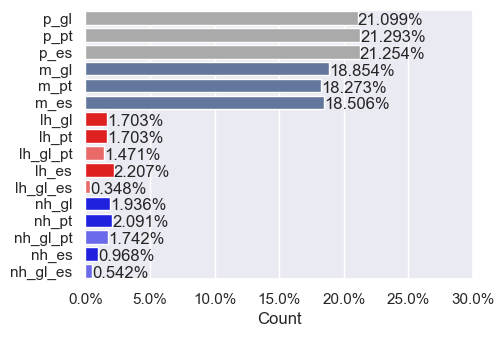

In [62]:
all_colors = {
'p_gl': '#aaaaaa',
'p_pt': '#aaaaaa',
'p_es': '#aaaaaa',
'm_gl': '#5975a4',
'm_pt': '#5975a4',
'm_es': '#5975a4',
'lh_gl': '#ff0000',
'lh_pt': '#ff0000',
'lh_gl_pt': '#ff5555',
'lh_es': '#ff0000',
'lh_gl_es': '#ff5555',
'nh_gl': '#0000ff',
'nh_pt': '#0000ff',
'nh_gl_pt': '#5555ff',
'nh_es': '#0000ff',
'nh_gl_es': '#5555ff'
}

all_colors = list(all_colors.values())
sns.set_palette(sns.color_palette(all_colors))
 
fig, ax = plt.subplots()
ax = sns.barplot(x="length", y="item", data=p_m_nh_lh_stats)
ax.xaxis.set_major_formatter(ticker.PercentFormatter(1.0))
ax.set(xlim=(0, 0.3))
show_values_on_bars_h(ax)
fig.set_size_inches(5, 3.5)
ax.set(xlabel="Count", ylabel="")

[Text(0.5, 0, 'Count'), Text(0, 0.5, '')]

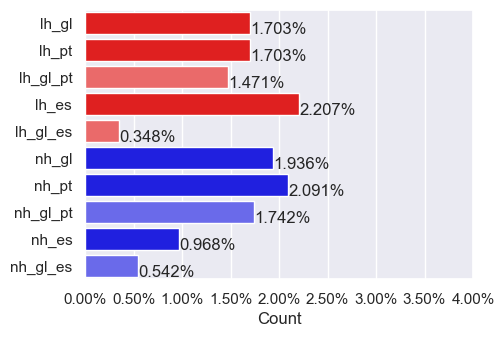

In [63]:
all_colors = {
'lh_gl': '#ff0000',
'lh_pt': '#ff0000',
'lh_gl_pt': '#ff5555',
'lh_es': '#ff0000',
'lh_gl_es': '#ff5555',
'nh_gl': '#0000ff',
'nh_pt': '#0000ff',
'nh_gl_pt': '#5555ff',
'nh_es': '#0000ff',
'nh_gl_es': '#5555ff'
}

all_colors = list(all_colors.values())
sns.set_palette(sns.color_palette(all_colors))

fig, ax = plt.subplots()
ax = sns.barplot(x="length", y="item", data=p_m_nh_lh_stats[6:16])
ax.xaxis.set_major_formatter(ticker.PercentFormatter(1.0))
ax.set(xlim=(0, 0.04))
show_values_on_bars_h(ax)
fig.set_size_inches(5, 3.5)
ax.set(xlabel="Count", ylabel="")